# 01: Ticket Classifier Model

In [3]:
#imports
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,
                            roc_auc_score, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

PROJECT = "ae-project-portfolio"
DATASET = "marts"
RAW = "support_raw"

client = bigquery.Client(project=PROJECT)

def query(sql):
    return client.query(sql).to_dataframe()

print("Imports complete!")

Imports complete!


## Load ticket + comment data
In this section, I will join the tickets to their first customer comment (the problem description). This is what the NLP mode will classify.

In [19]:
tickets = query(f"""
with first_comments as (
    select
        ticket_id,
        body as first_comment,
        row_number() over (
            partition by ticket_id
            order by created_at
        ) as rn
    from `{PROJECT}.{RAW}.ticket_comments`
    where author_type = 'customer'
),

final as (
    select
        t.ticket_id,
        t.category,
        t.priority,
        t.channel,
        t.is_escalated,
        t.sla_breached,
        t.csat_score,
        t.status,
        c.first_comment
    from `{PROJECT}.{DATASET}.fct_tickets` t
    left join first_comments c
        on t.ticket_id = c.ticket_id
        and c.rn = 1
    where c.first_comment is not null
)

select * from final
""")

print(f"Dataset: {len(tickets):,} tickets with comments")
print(f"\nCategory distribution:")
print(tickets['category'].value_counts())
print(f"\nEscalation rate: {tickets['is_escalated'].mean()*100:.1f}%")

Dataset: 20,000 tickets with comments

Category distribution:
category
performance        3392
bug                3377
account            3374
billing            3313
integration        3289
feature_request    3255
Name: count, dtype: int64

Escalation rate: 5.8%


## NLP category classifier
The first model will predict ticket category from comment text. This is useful for auto-routing tickets to the right team

In [6]:
X_text = tickets['first_comment']
y_cat = tickets['category']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

#TF-IDF + Logistic Regression pipeline
category_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english',
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0
    ))
])

category_pipeline.fit(X_train, y_train)
y_pred = category_pipeline.predict(X_test)

print("Category Classifier Performance:")
print(classification_report(y_test, y_pred))

Category Classifier Performance:
                 precision    recall  f1-score   support

        account       1.00      1.00      1.00       675
        billing       1.00      1.00      1.00       663
            bug       1.00      1.00      1.00       675
feature_request       1.00      1.00      1.00       651
    integration       1.00      1.00      1.00       658
    performance       1.00      1.00      1.00       678

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



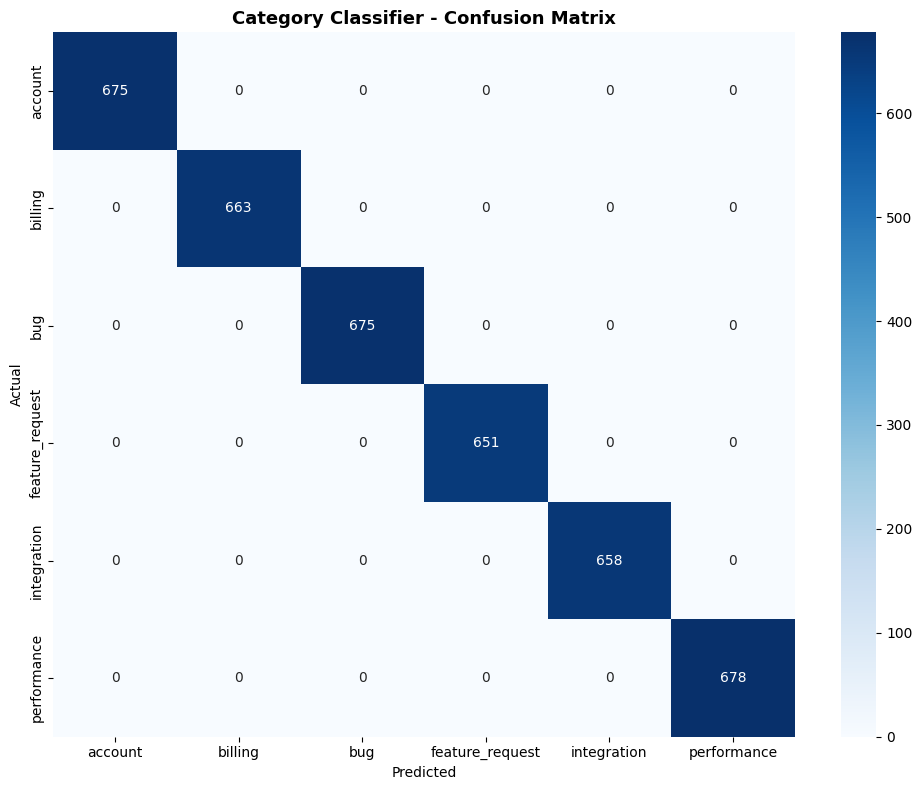

In [8]:
#confusion matrix for category classifier
cm = confusion_matrix(y_test, y_pred, labels=category_pipeline.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=category_pipeline.classes_,
           yticklabels=category_pipeline.classes_,
           ax=ax)
ax.set_title('Category Classifier - Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('category_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Top TF-IDF features per category
What words drive each category prediction?

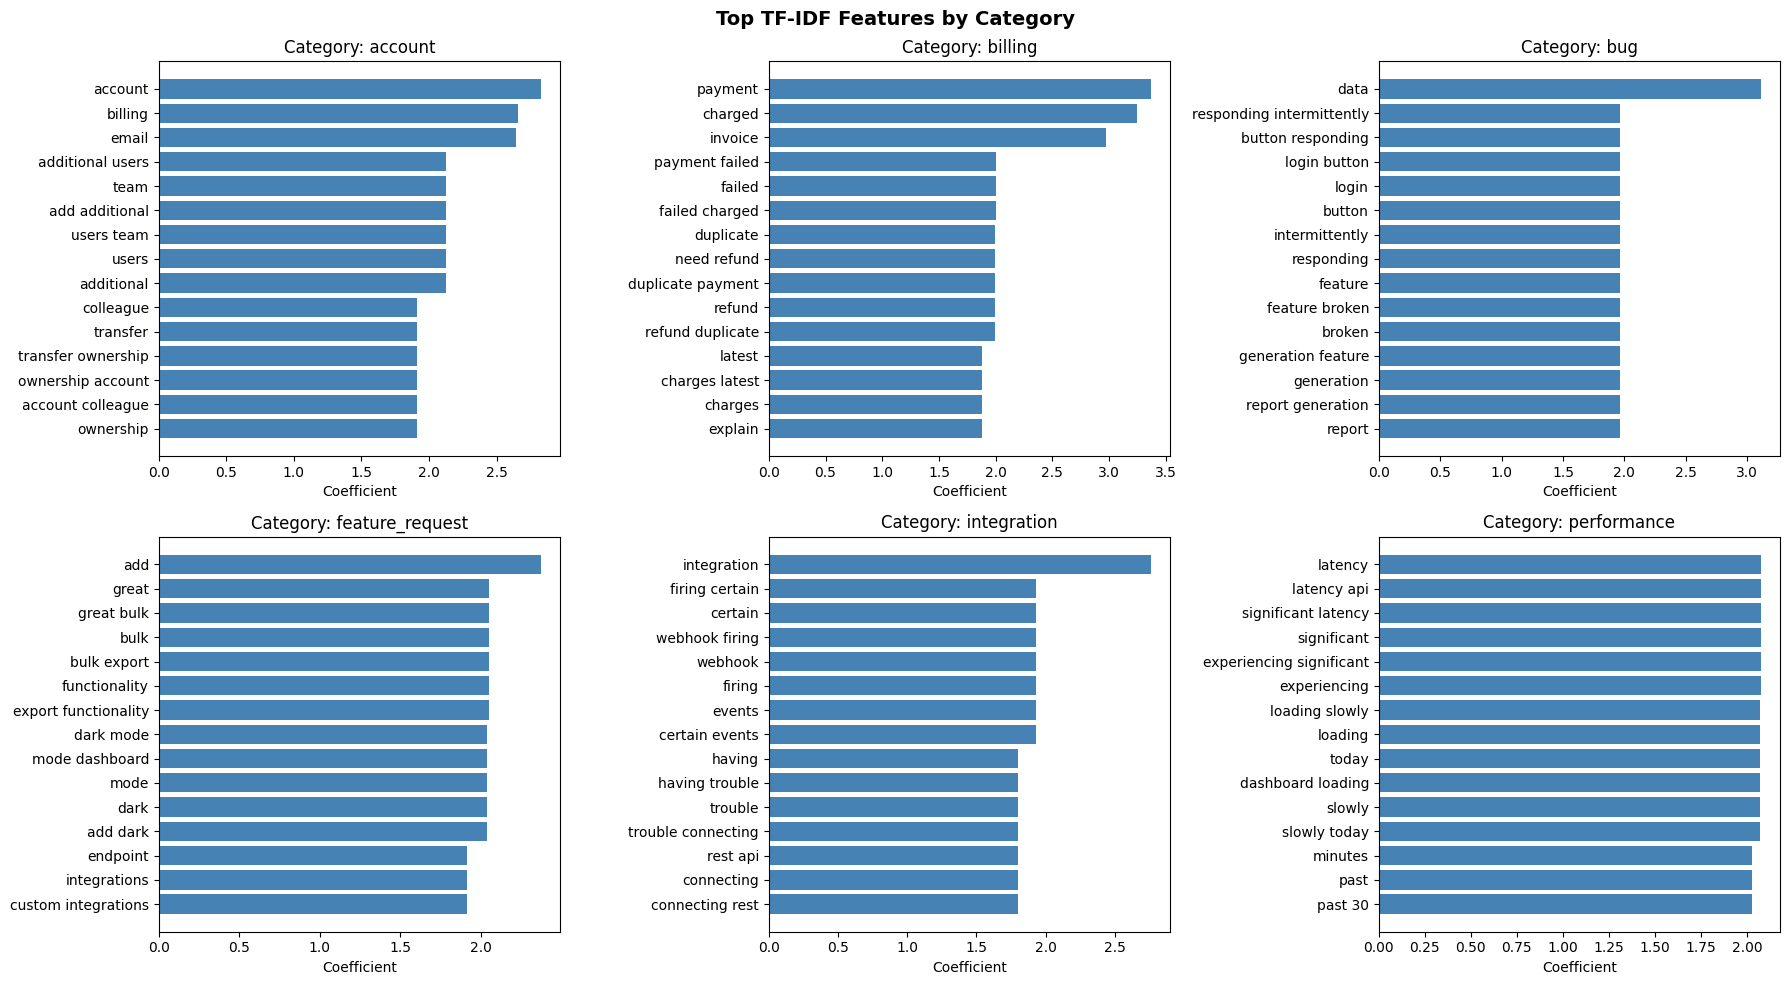

In [12]:
tfidf = category_pipeline.named_steps['tfidf']
clf = category_pipeline.named_steps['clf']
vocab = tfidf.get_feature_names_out()
categories = clf.classes_

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top TF-IDF Features by Category', fontsize=14, fontweight='bold')

for i, (cat, ax) in enumerate(zip(categories, axes.flatten())):
    coefs = clf.coef_[i]
    top_idx = coefs.argsort()[-15:][::-1]
    top_words = [vocab[j] for j in top_idx]
    top_scores = [coefs[j] for j in top_idx]

    ax.barh(top_words[::-1], top_scores[::-1], color='steelblue')
    ax.set_title(f"Category: {cat}")
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Escalation predictor
The second model will predict whether a ticket will escalate. Uses both text features and & structured features

In [20]:
# structured features
struct_features = [
    'priority', 'channel', 'category', 'sla_breached'
]

df = tickets.copy()

# encode categoricals
le = LabelEncoder()
for col in ['priority', 'channel', 'category']:
    df[col] = le.fit_transform(df[col].astype(str))

df['sla_breached'] = df['sla_breached'].astype(int)

X_struct = df[struct_features]
y_esc    = df['is_escalated'].astype(int)

# also get TF-IDF features from text
tfidf_esc = TfidfVectorizer(max_features=500, ngram_range=(1,2),
                             stop_words='english')
X_tfidf = pd.DataFrame(
    tfidf_esc.fit_transform(df['first_comment']).toarray(),
    columns=[f'tfidf_{w}' for w in tfidf_esc.get_feature_names_out()]
)

# combine structured + text features
X_combined = pd.concat([
    X_struct.reset_index(drop=True),
    X_tfidf.reset_index(drop=True)
], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_esc,
    test_size=0.2, random_state=42, stratify=y_esc
)

# XGBoost with class imbalance handling
scale = (y_train == 0).sum() / (y_train == 1).sum()

escalation_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

escalation_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_prob = escalation_model.predict_proba(X_test)[:, 1]
y_pred = escalation_model.predict(X_test)
auc    = roc_auc_score(y_test, y_prob)

print(f"Escalation Model ROC-AUC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Not Escalated', 'Escalated']))

Escalation Model ROC-AUC: 0.9605

Classification Report:
               precision    recall  f1-score   support

Not Escalated       1.00      0.91      0.95      3766
    Escalated       0.39      0.99      0.56       234

     accuracy                           0.91      4000
    macro avg       0.70      0.95      0.76      4000
 weighted avg       0.96      0.91      0.93      4000



### Escalation Model Results - AUC 0.96

**Model:** XGBoost classifier combining TF-IDF text features from the first customer comment with structure features (priority, channel, category, sla_breached).</br>

**Key Metrics:**
- ROC-AUC: 0.96 - strong overall discrimination
- Recall on escalations: 0.99 - model catches nearly every real escalation
- Precision on escalations: 0.39 - some false positives, acceptabl tradeoff </br>

**Design decision - optimizing for recall over precision:**
In a support context, mission a real escalation (false negative) if far more costly than incorrectly flagging a ticket (false positive). A missed escalation means an unhappy customer gets no proactive attention. A false positive just means an agent checks in on a ticket that didn't need it. </br>

The `scale_pos_weight` parameter in XGBoost handles class imbalance (~6% escalation rate) and naturally pushes the model toward high recall. </br>

**Most predictive structured features:** priority and sla_breached confirming the findings from the SLA analysis notebook.

## Escalation model evaluation

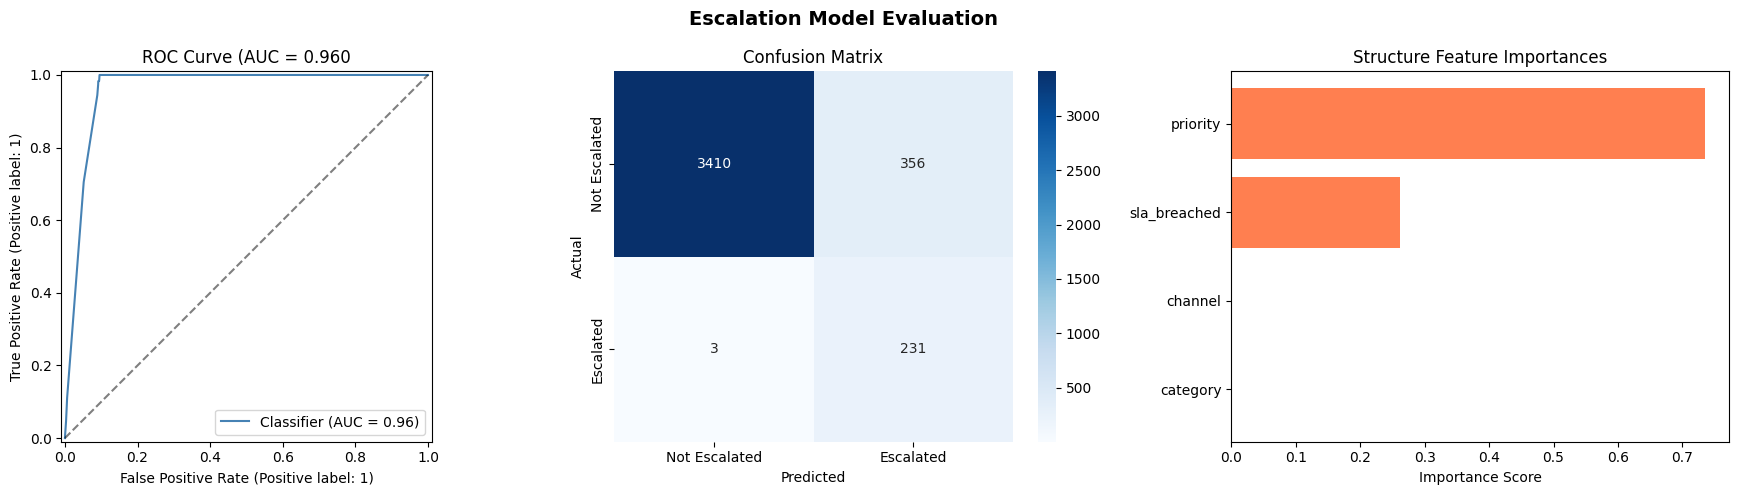

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Escalation Model Evaluation', fontsize=14, fontweight='bold')

#ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0],
                                color='steelblue')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_title(f'ROC Curve (AUC = {auc:.3f}')

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
           xticklabels=['Not Escalated', 'Escalated'],
           yticklabels=['Not Escalated', 'Escalated'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

#feature importance (top 20 structured features only)
struct_importances = pd.DataFrame({
    'feature': X_combined.columns,
    'importance': escalation_model.feature_importances_
})
struct_importances = struct_importances[
    ~struct_importances['feature'].str.startswith('tfidf_')
].sort_values('importance', ascending=True)

axes[2].barh(struct_importances['feature'],
            struct_importances['importance'], color='coral')
axes[2].set_title('Structure Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('escalation_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## Score all tickets & write back to BigQuery
Score full dataset with both model

In [26]:
df['predicted_category'] = category_pipeline.predict(df['first_comment'])
df['category_confidence'] = category_pipeline.predict_proba(
    df['first_comment']).max(axis=1).round(4)
df['escalation_probability'] = escalation_model.predict_proba(
    X_combined)[:, 1].round(4)
df['escalation_prediction'] = escalation_model.predict(X_combined)
df['escalation_risk_tier'] = pd.cut(
    df['escalation_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['low', 'medium', 'high', 'critical']
).astype(str)

scores = df[[
    'ticket_id',
    'predicted_category',
    'category_confidence',
    'escalation_probability',
    'escalation_prediction',
    'escalation_risk_tier'
]].copy()

scores['scored_at'] = pd.Timestamp.utcnow()

print(f"Scores shape: {scores.shape}")
print(f"\nEscalation risk distribution:")
print(scores['escalation_risk_tier'].value_counts().sort_index())

#write to BigQuery
destination = f"{PROJECT}.support_raw.ticket_ml_scores"
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("ticket_id", "STRING"),
        bigquery.SchemaField("predicted_category", "STRING"),
        bigquery.SchemaField("category_confidence", "FLOAT"),
        bigquery.SchemaField("escalation_probability", "FLOAT"),
        bigquery.SchemaField("escalation_prediction", "INTEGER"),
        bigquery.SchemaField("escalation_risk_tier", "STRING"),
        bigquery.SchemaField("scored_at", "TIMESTAMP")
    ]
)

job = client.load_table_from_dataframe(scores, destination,
                                      job_config=job_config)
job.result()
print(f"\nWritten {len(scores):,} rows to {destination}")

Scores shape: (20000, 7)

Escalation risk distribution:
escalation_risk_tier
high       3048
medium    16952
Name: count, dtype: int64

Written 20,000 rows to ae-project-portfolio.support_raw.ticket_ml_scores


In [27]:
#saving model artifacts
import os
os.makedirs('models', exist_ok=True)

joblib.dump(category_pipeline, 'models/category_classifier.pkl')
joblib.dump(escalation_model, 'models/escalation_model.pkl')
joblib.dump(tfidf_esc, 'models/escalation_tfidf.pkl')
joblib.dump(list(X_combined.columns), 'models/escalation_feature_cols.pkl')

print('category_classifier.pkl saved!')
print('escalation_model.pkl saved!')
print('escalation_tfidf.pkl saved!')
print('escalation_feature_cols.pkl saved!')

category_classifier.pkl saved!
escalation_model.pkl saved!
escalation_tfidf.pkl saved!
escalation_feature_cols.pkl saved!
